
# Hypothesis Testing for Bioengineering  
## Complete Tutorial (Z-test and t-test)

This notebook includes:

- Mathematical foundation
- Z-test with formula
- One-sample t-test with formula
- p-value explanation
- Confidence intervals
- Synthetic biomedical data
- Real biomedical dataset
- Clean scientific visualizations (one plot per figure)


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import load_breast_cancer

np.random.seed(42)



# 1. Mathematical Foundations

## Hypotheses

Null hypothesis:
$$
H_0: \mu = \mu_0
$$

Alternative hypothesis:
$$
H_1: \mu \neq \mu_0
$$

## Test Statistic

General form:
$$
\text{Statistic} = \frac{\text{Observed} - \text{Expected}}{\text{Standard Error}}
$$

## p-value

The p-value is:

> Probability of observing a statistic as extreme as ours, assuming $H_0$ is true.

Decision rule (α = 0.05):
- If p < 0.05 → Reject $H_0$
- If p ≥ 0.05 → Fail to reject $H_0$



# 2. Z-Test

Used when:
- Large sample (n ≥ 30)
- Population standard deviation known

Formula:
$$
Z = \frac{\bar{x} - \mu_0}{\sigma / \sqrt{n}}
$$



## Synthetic Example: Heart Rate

Normal mean = 70 bpm.


In [6]:

population_mean = 70
population_std = 10

sample = np.random.normal(loc=73, scale=10, size=100)

sample_mean = np.mean(sample)
n = len(sample)

z_stat = (sample_mean - population_mean) / (population_std / np.sqrt(n))
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

sample_mean, z_stat, p_value


(71.96153482605907, 1.961534826059065, 0.049816666558650136)

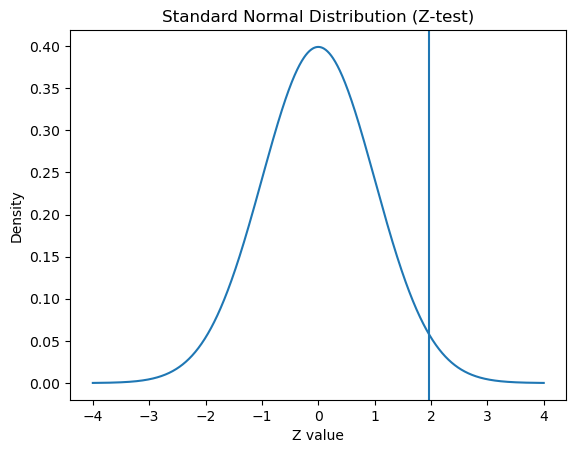

In [7]:

# Standard normal distribution plot
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

plt.plot(x, y)
plt.axvline(z_stat)
plt.title("Standard Normal Distribution (Z-test)")
plt.xlabel("Z value")
plt.ylabel("Density")
plt.show()



## Confidence Interval (Z-based)

$$
\bar{x} \pm Z_{\alpha/2} \frac{\sigma}{\sqrt{n}}
$$


In [9]:

alpha = 0.05
z_critical = stats.norm.ppf(1 - alpha/2)

margin_error = z_critical * (population_std / np.sqrt(n))
ci_lower = sample_mean - margin_error
ci_upper = sample_mean + margin_error

(ci_lower, ci_upper)


(70.00157084151901, 73.92149881059912)


# 3. One-Sample t-Test

Used when:
- Population variance unknown

Formula:
$$
t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}
$$

Degrees of freedom:
$$
df = n - 1
$$



## Synthetic Example: Glucose Level


In [13]:

glucose = np.random.normal(loc=110, scale=15, size=20)

t_stat, p_value_t = stats.ttest_1samp(glucose, 100)

np.mean(glucose), t_stat, p_value_t


(110.66327384951816, 3.108678070665786, 0.005782159464932288)

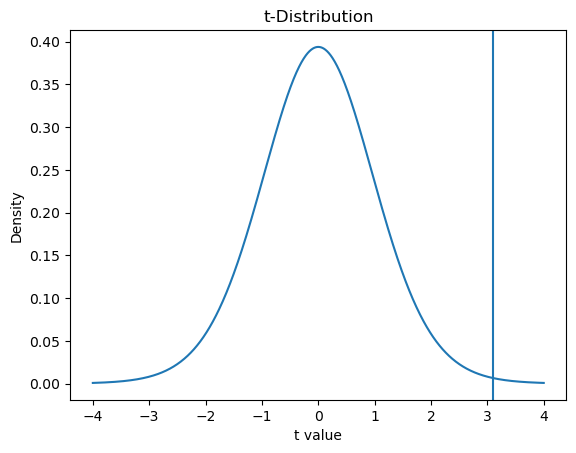

In [14]:

df = len(glucose) - 1
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df)

plt.plot(x, y)
plt.axvline(t_stat)
plt.title("t-Distribution")
plt.xlabel("t value")
plt.ylabel("Density")
plt.show()



## Confidence Interval (t-based)

$$
\bar{x} \pm t_{\alpha/2, df} \frac{s}{\sqrt{n}}
$$


In [16]:

mean_g = np.mean(glucose)
sem = stats.sem(glucose)
t_critical = stats.t.ppf(0.975, df)

margin_error = t_critical * sem

ci_lower = mean_g - margin_error
ci_upper = mean_g + margin_error

(ci_lower, ci_upper)


(103.48385926928658, 117.84268842974974)


# 4. Real Biomedical Dataset

Breast Cancer dataset (sklearn).
Test if mean tumor radius differs from 14.


In [19]:

data = load_breast_cancer()
radius = data.data[:, 0]

np.mean(radius)


14.127291739894552

In [20]:

t_stat_real, p_value_real = stats.ttest_1samp(radius, 14)

t_stat_real, p_value_real


(0.8616173566232037, 0.3892617071079777)

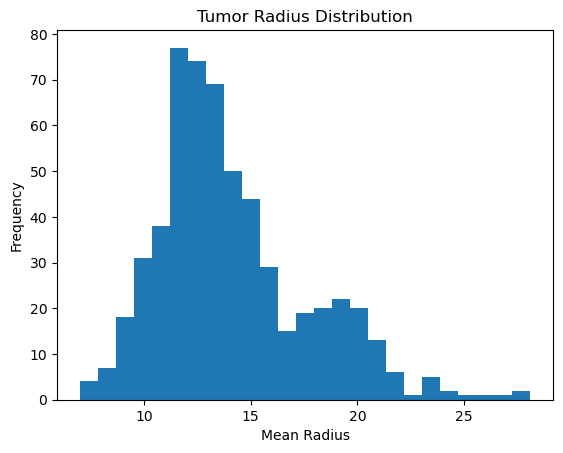

In [21]:

plt.hist(radius, bins=25)
plt.title("Tumor Radius Distribution")
plt.xlabel("Mean Radius")
plt.ylabel("Frequency")
plt.show()



# Summary

This notebook demonstrated:

- Mathematical derivation of Z-test and t-test
- p-value interpretation
- Confidence intervals
- Synthetic biomedical examples
- Real dataset application
- Clean scientific visualization

These methods are essential in bioengineering research and clinical data analysis.
